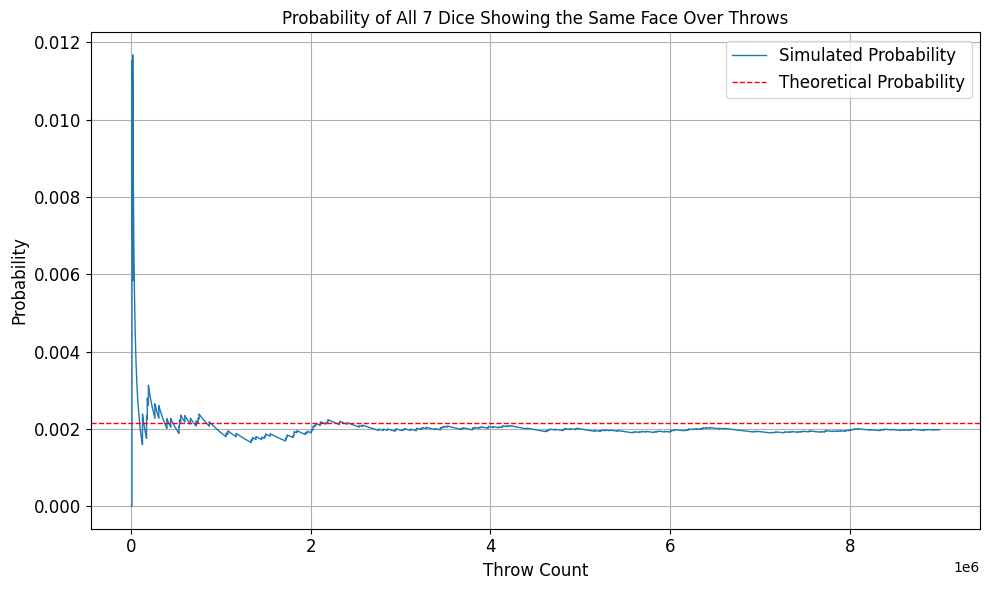

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dice.txt')
df.columns = df.columns.str.strip()

theoretical_prob = 1 / (6 ** 6) * 100  # ≈ 0.0000214 * 100

plt.figure(figsize=(10, 6))

plt.plot(df['throw_count'], df['percentage'], linestyle='-', linewidth=1, label='Simulated Probability')
plt.axhline(y=theoretical_prob, color='red', linestyle='--', linewidth=1, label='Theoretical Probability')

plt.xlabel('Throw Count', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability of All 7 Dice Showing the Same Face Over Throws', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()



   index  radius      x      y  withinCount  percentageWithin  theoretical
0      0     7.0 -6.400  1.512            1          1.000000     0.785398
1      1     7.0 -0.693 -6.072            2          1.000000     0.785398
2      2     7.0  6.395 -6.877            2          0.666667     0.785398
3      3     7.0 -3.823 -2.029            3          0.750000     0.785398
4      4     7.0  0.612 -0.052            4          0.800000     0.785398


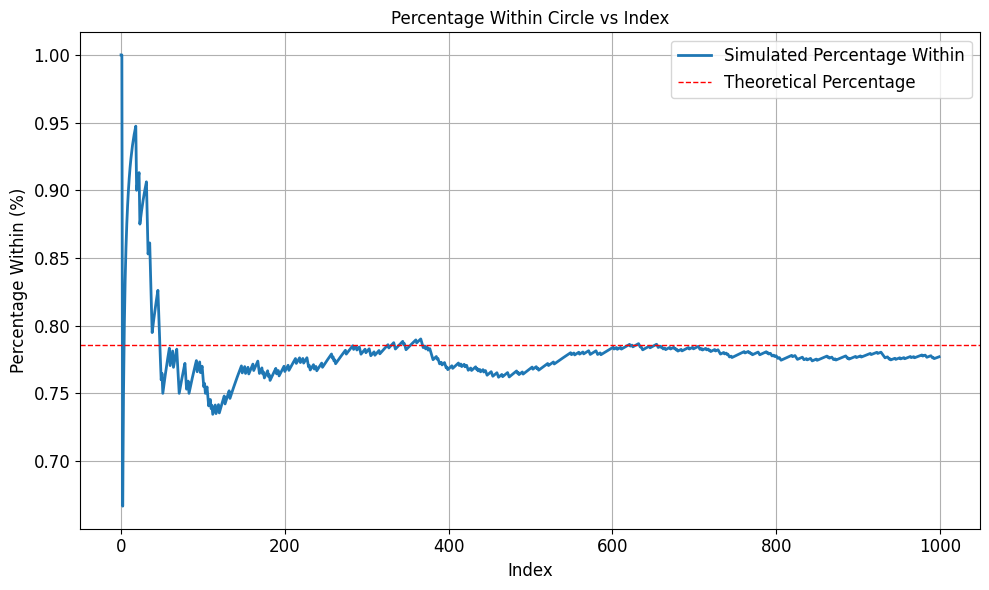

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Assign proper column names according to your data
cols = ['index', 'radius', 'x', 'y', 'withinCount', 'percentageWithin', 'theoretical']

# Read CSV, skip first row, use cols for headers
df = pd.read_csv('area.txt', skiprows=1, names=cols)

# Inspect to verify
print(df.head())

# Plot percentageWithin over index (or x/y as you want)
plt.figure(figsize=(10, 6))

plt.plot(df['index'], df['percentageWithin'], linestyle='-', linewidth=2, label='Simulated Percentage Within')

plt.axhline(y=df['theoretical'][0], color='red', linestyle='--', linewidth=1, label='Theoretical Percentage')

plt.xlabel('Index', fontsize=12)
plt.ylabel('Percentage Within (%)', fontsize=12)
plt.title('Percentage Within Circle vs Index', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


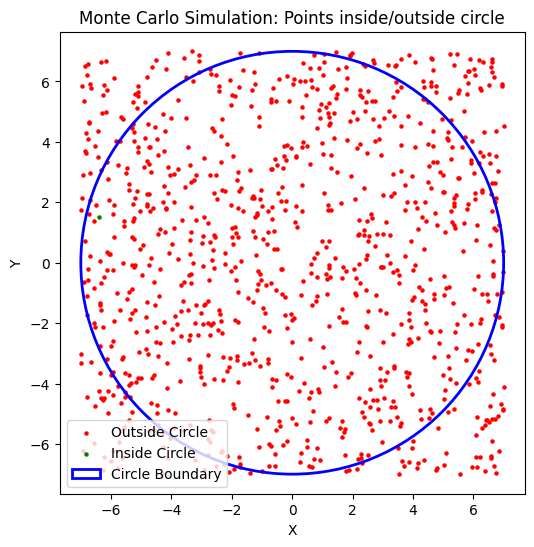

In [73]:
import matplotlib.pyplot as plt

# Load CSV data: columns = index,radius,x,y,withinCount,percentageWithin,theoretical
filename = "area.txt"

x_in, y_in = [], []
x_out, y_out = [], []

with open(filename, 'r') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 7:
            continue

        x = float(parts[2])
        y = float(parts[3])
        is_within = int(parts[4])

        if is_within == 1:
            x_in.append(x)
            y_in.append(y)
        else:
            x_out.append(x)
            y_out.append(y)

# Plot points
plt.figure(figsize=(6,6))
plt.scatter(x_out, y_out, color='red', s=5, label='Outside Circle')
plt.scatter(x_in, y_in, color='green', s=5, label='Inside Circle')

# Draw the circle boundary
radius = max(max(abs(x) for x in x_in + x_out), max(abs(y) for y in y_in + y_out))
circle = plt.Circle((0, 0), radius, color='blue', fill=False, linewidth=2, label='Circle Boundary')
plt.gca().add_artist(circle)

plt.axis('equal')
plt.legend()
plt.title('Monte Carlo Simulation: Points inside/outside circle')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


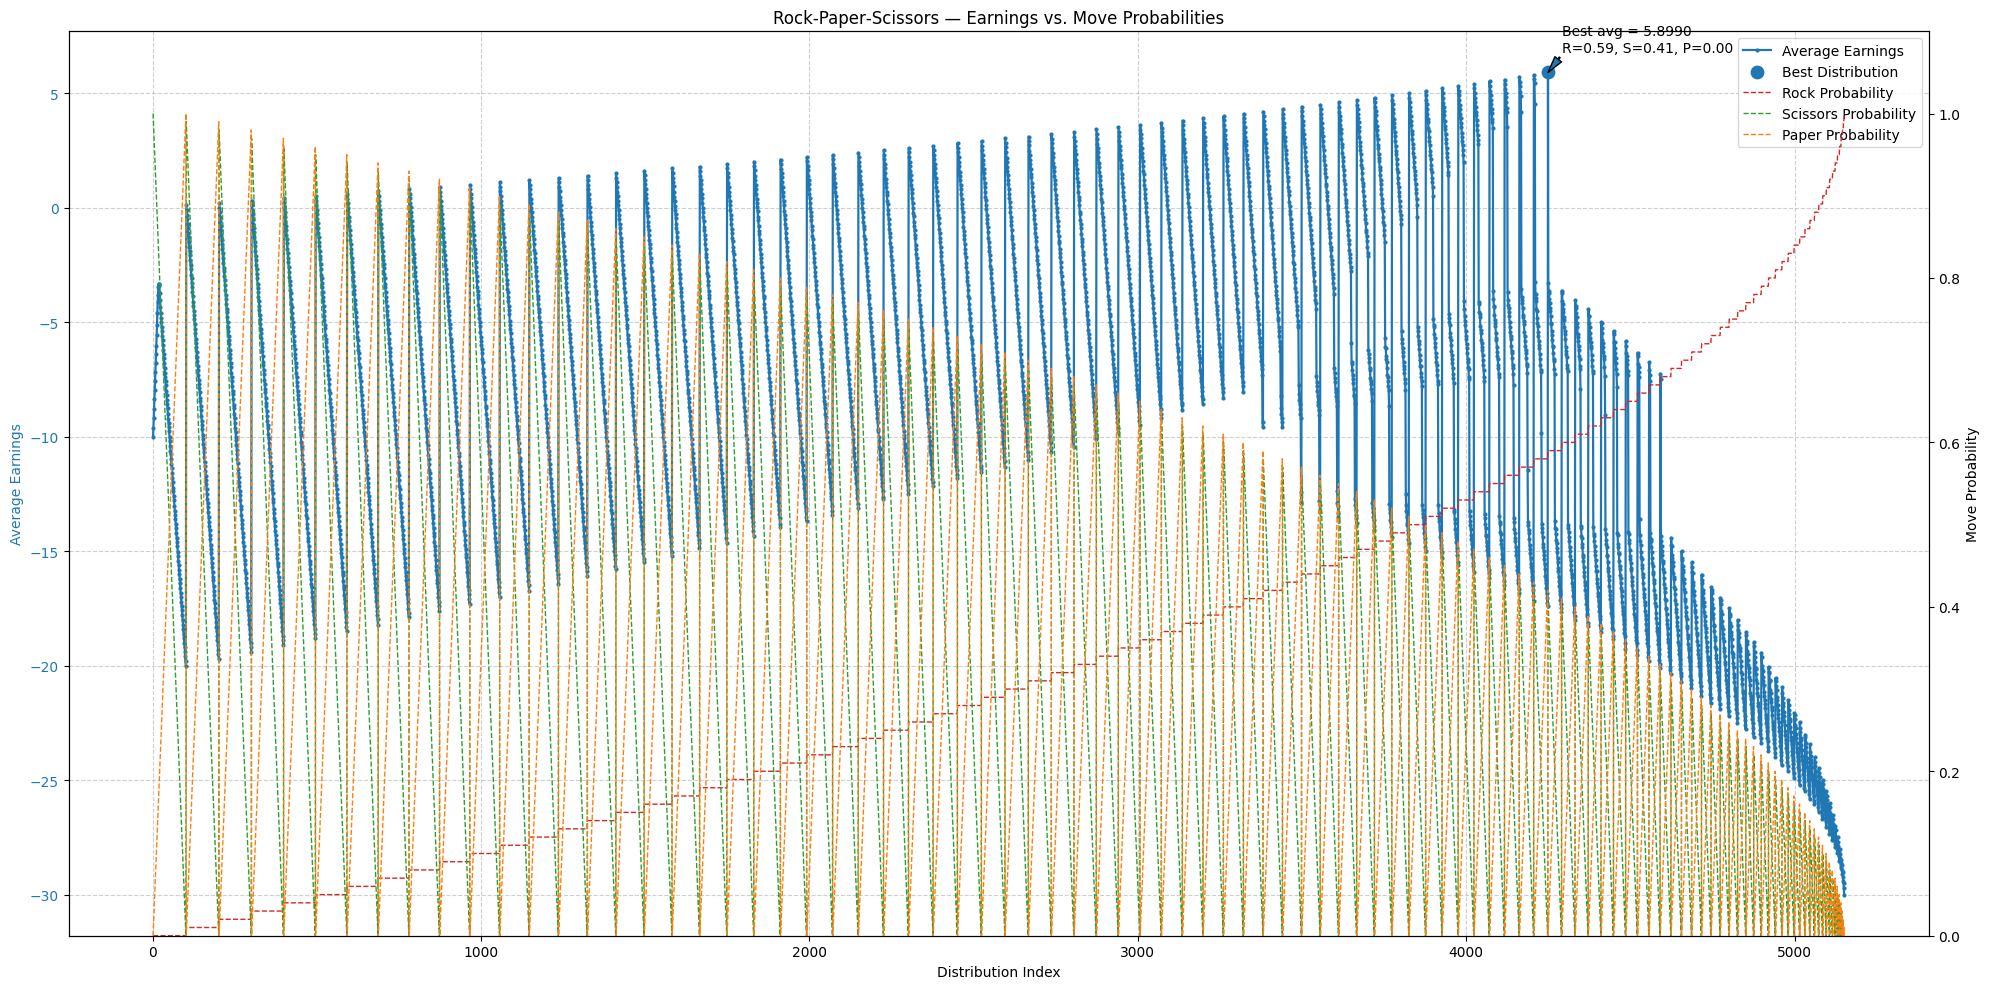

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("janken-ai.txt")

best_row = df.loc[df['average_earnings'].idxmax()]

fig, ax1 = plt.subplots(figsize=(20, 10))

# ── left axis: average earnings ────────────────────────────────────
ax1.plot(df['distribution_index'], df['average_earnings'],
         marker='o', markersize=2, linewidth=1.6,
         color='tab:blue', label='Average Earnings')
ax1.set_xlabel('Distribution Index')
ax1.set_ylabel('Average Earnings', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# ── right axis: probabilities, scaled 0‒1 over full height ────────
ax2 = ax1.twinx()
ax2.plot(df['distribution_index'], df['rock_prob'],
         linestyle='--', linewidth=1.0, color='tab:red',
         label='Rock Probability')
ax2.plot(df['distribution_index'], df['scissors_prob'],
         linestyle='--', linewidth=1.0, color='tab:green',
         label='Scissors Probability')
ax2.plot(df['distribution_index'], df['paper_prob'],
         linestyle='--', linewidth=1.0, color='tab:orange',
         label='Paper Probability')
ax2.set_ylabel('Move Probability', color='black')
ax2.set_ylim(0, 1.1)                   # full height for 0‒1
ax2.tick_params(axis='y')

# ── highlight best distribution (optional) ────────────────────────
ax1.scatter(best_row['distribution_index'], best_row['average_earnings'],
            s=80, zorder=1, label='Best Distribution')
ax1.annotate(
    f"Best avg = {best_row['average_earnings']:.4f}\n"
    f"R={best_row['rock_prob']:.2f}, "
    f"S={best_row['scissors_prob']:.2f}, "
    f"P={best_row['paper_prob']:.2f}",
    xy=(best_row['distribution_index'], best_row['average_earnings']),
    xytext=(10, 15), textcoords="offset points",
    arrowprops=dict(width=0.8, headwidth=6)
)

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Rock‑Paper‑Scissors — Earnings vs. Move Probabilities')
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()


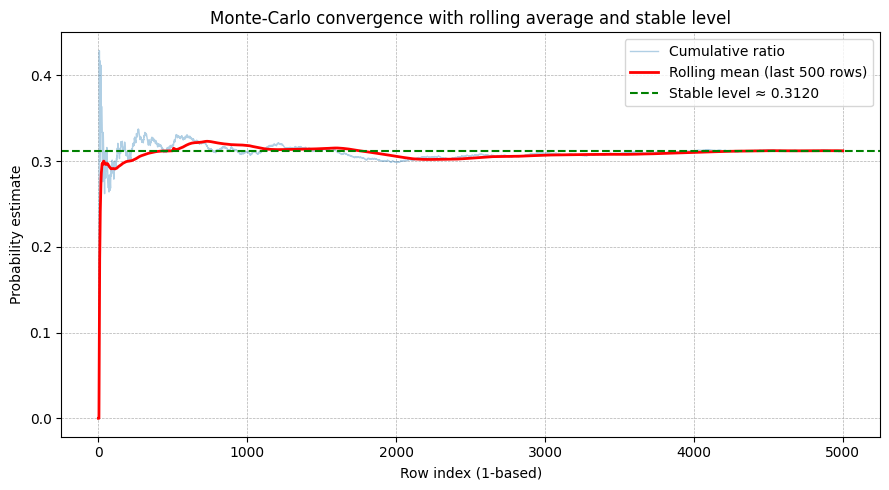

In [20]:
import csv
import matplotlib.pyplot as plt
from collections import deque

# ---------------- CONFIG ----------------
FILENAME      = "height.txt"   # adjust path if needed
ROLL_WINDOW   = 500             # rolling mean window size
STABLE_SPAN   = 1000             # how many last rows to average for a "stable" level
# ----------------------------------------

trials, ratio, rolling = [], [], []
q = deque()
acc = 0.0

with open(FILENAME, newline="") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header
    for idx, row in enumerate(reader, start=1):
        if len(row) < 3:
            continue
        r = float(row[2])
        trials.append(idx)
        ratio.append(r)

        # Rolling mean
        q.append(r); acc += r
        if len(q) > ROLL_WINDOW:
            acc -= q.popleft()
        rolling.append(acc / len(q))

# --- Stable horizontal line: mean of last STABLE_SPAN ratios
tail = ratio[-STABLE_SPAN:] if len(ratio) >= STABLE_SPAN else ratio
stable_level = sum(tail) / len(tail) if tail else 0.0

# --- Plot -------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(trials, ratio,  lw=1, alpha=0.35, label="Cumulative ratio")
plt.plot(trials, rolling, lw=2, color="red",
         label=f"Rolling mean (last {ROLL_WINDOW} rows)")

# Horizontal stable level
plt.axhline(stable_level, color="green", linestyle="--",
            label=f"Stable level ≈ {stable_level:.4f}")

plt.xlabel("Row index (1‑based)")
plt.ylabel("Probability estimate")
plt.title("Monte‑Carlo convergence with rolling average and stable level")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


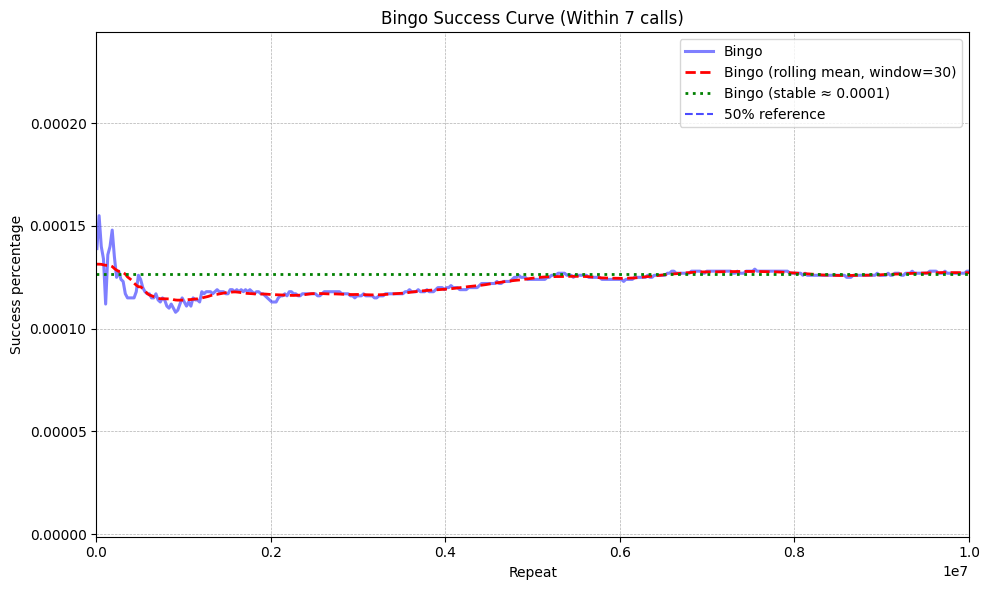

In [3]:
#!/usr/bin/env python3
"""
Plot Bingo simulation results from a CSV file.
Uses smooth line graphs with interpolation, rolling average, and stable level.
Only shows successful Bingo results (percentage > 0).
"""
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# ---------------- CONFIG ----------------
FILENAME = "bingo-1.txt"
ROLL_WINDOW = 30     # smoothing window on interpolated data
STABLE_SPAN = 50     # how many last points to average
# ----------------------------------------

success_x, success_y = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            repeat = int(row["repeat"])
            pct = float(row["percentage"])
            if pct > 0:
                success_x.append(repeat)
                success_y.append(pct)
        except (ValueError, KeyError):
            continue

# ── choose y-axis limits ──────────────────────────────────────────────────────
if success_y:
    ymax = max(success_y)
else:
    ymax = 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# ── plot interpolated data ─────────────────────────────────────────────────────
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np, y_np = np.array(x), np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted, y_sorted = x_np[sorted_idx], y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)
    
    # ── Main smooth curve ──────────────────────────────────────────
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # ── Rolling mean ───────────────────────────────────────────────
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # ── Stable final average ───────────────────────────────────────
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.4f})")


# ── Plot setup ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

if success_x:
    sorted_spline(success_x, success_y, color="blue", label="Bingo")

plt.axhline(0.5, color="blue", linestyle="--", linewidth=1.5, alpha=0.7, label="50% reference")

plt.title("Bingo Success Curve (Within 7 calls)")
plt.xlabel("Repeat")
plt.ylabel("Success percentage")
plt.xlim(0, max(success_x, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


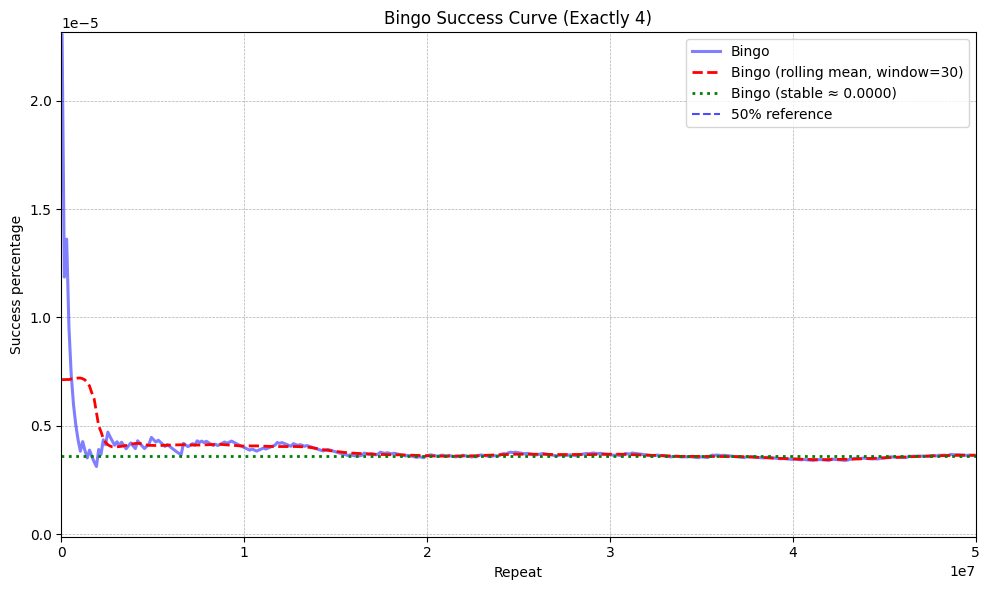

In [20]:
#!/usr/bin/env python3
"""
Plot Bingo simulation results from a CSV file.
Uses smooth line graphs with interpolation, rolling average, and stable level.
Only shows successful Bingo results (percentage > 0).
"""
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# ---------------- CONFIG ----------------
FILENAME = "bingo-2.txt"
ROLL_WINDOW = 30     # smoothing window on interpolated data
STABLE_SPAN = 50     # how many last points to average
# ----------------------------------------

success_x, success_y = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            repeat = int(row["repeat"])
            pct = float(row["percentage"])
            if pct > 0:
                success_x.append(repeat)
                success_y.append(pct)
        except (ValueError, KeyError):
            continue

# ── choose y-axis limits ──────────────────────────────────────────────────────
if success_y:
    ymax = max(success_y)
else:
    ymax = 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# ── plot interpolated data ─────────────────────────────────────────────────────
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np, y_np = np.array(x), np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted, y_sorted = x_np[sorted_idx], y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)
    
    # ── Main smooth curve ──────────────────────────────────────────
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # ── Rolling mean ───────────────────────────────────────────────
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # ── Stable final average ───────────────────────────────────────
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.4f})")


# ── Plot setup ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

if success_x:
    sorted_spline(success_x, success_y, color="blue", label="Bingo")

plt.axhline(0.5, color="blue", linestyle="--", linewidth=1.5, alpha=0.7, label="50% reference")

plt.title("Bingo Success Curve (Exactly 4)")
plt.xlabel("Repeat")
plt.ylabel("Success percentage")
plt.xlim(0, max(success_x, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


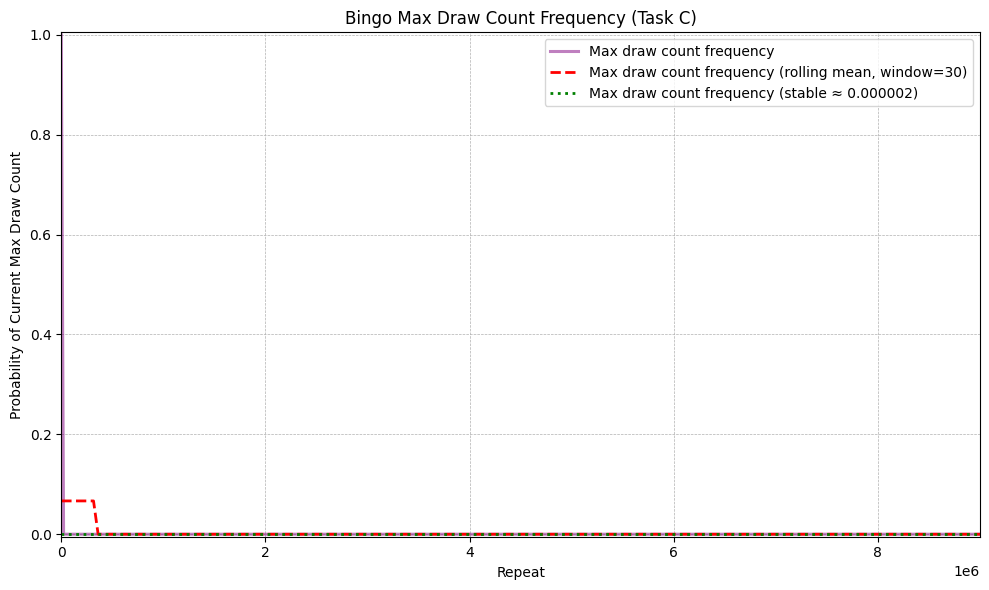

In [17]:
#!/usr/bin/env python3
"""
Plot Bingo simulation results from a CSV file for Task C.
Shows the frequency of the *current maximum* Bingo call count observed so far.
Only includes lines where percentage > 0.
"""
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# ---------------- CONFIG ----------------
FILENAME = "bingo-3.txt"  # Adjust to your actual CSV file name
ROLL_WINDOW = 30          # Smoothing window
STABLE_SPAN = 50          # Final segment to average for stable line
# ----------------------------------------

x_data, y_data = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            repeat = int(row["repeat"])
            pct = float(row["percentage"])
            if pct > 0:
                x_data.append(repeat)
                y_data.append(pct)
        except (ValueError, KeyError):
            continue

# ── Axis limit calculation ─────────────────────────────────────────────────────
if y_data:
    ymax = max(y_data)
else:
    ymax = 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# ── Interpolated smooth plot with extras ────────────────────────────────────────
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np, y_np = np.array(x), np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted, y_sorted = x_np[sorted_idx], y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)

    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # Rolling average line
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # Stable segment average
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.6f})")


# ── Plot setup ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

if x_data:
    sorted_spline(x_data, y_data, color="purple", label="Max draw count frequency")

plt.title("Bingo Max Draw Count Frequency (Task C)")
plt.xlabel("Repeat")
plt.ylabel("Probability of Current Max Draw Count")
plt.xlim(0, max(x_data, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


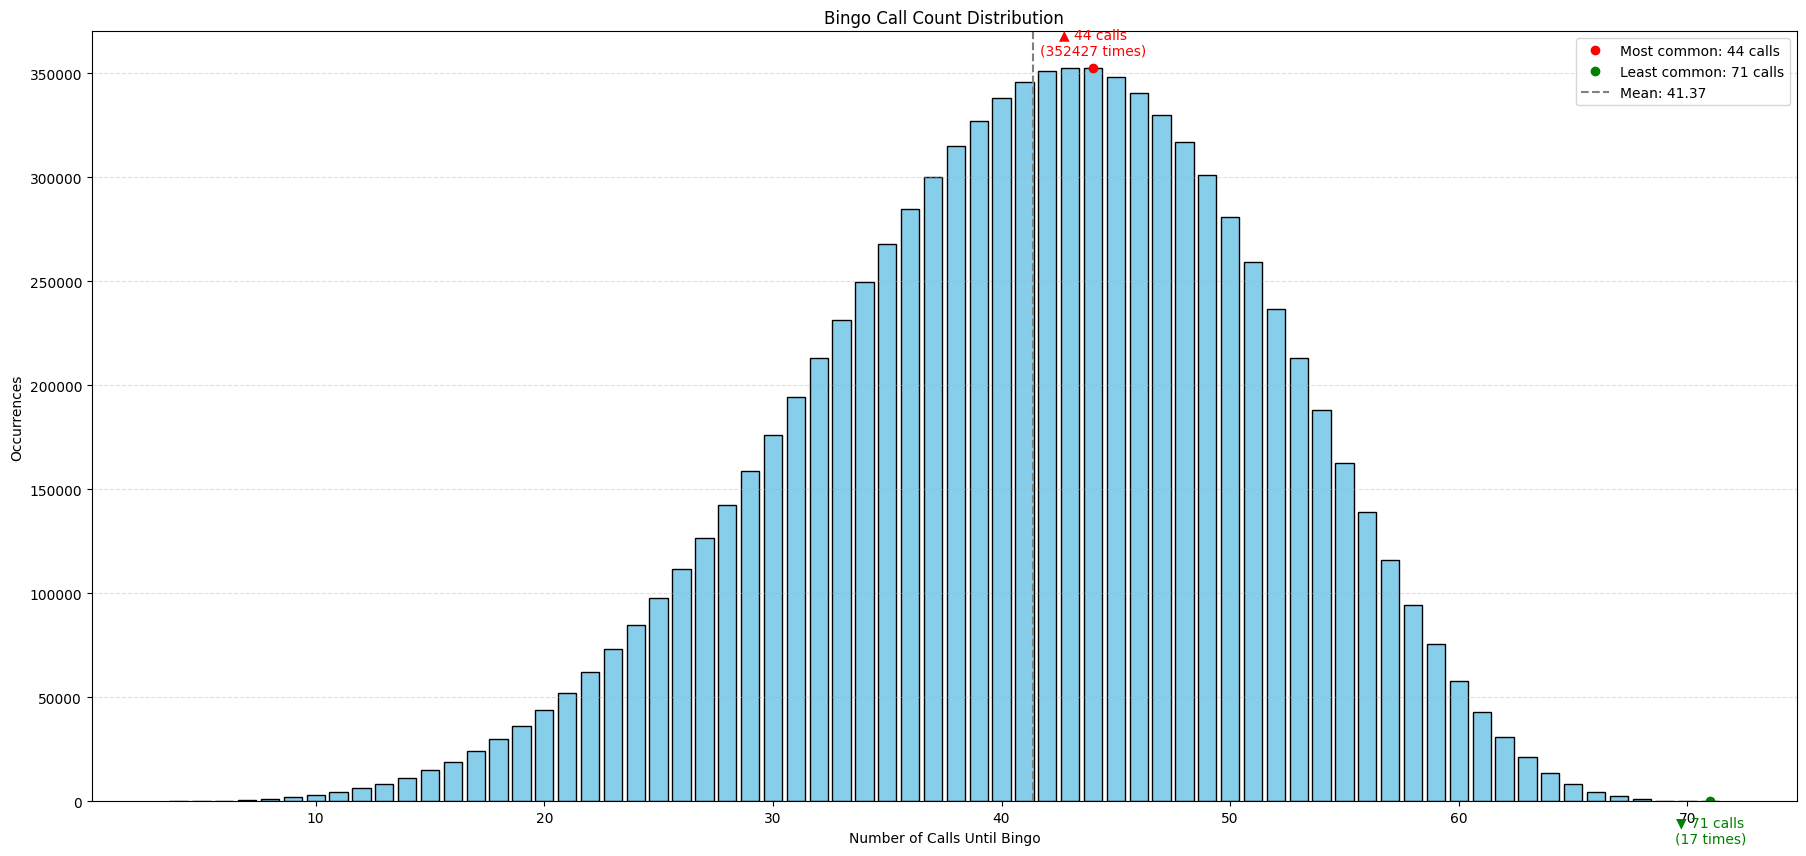

In [ ]:
#!/usr/bin/env python3
"""
Plot Bingo call count distribution from a CSV file.
Highlights which number of calls appears most and least frequently.
"""

import csv
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
FILENAME = "call_distribution.csv"
TITLE = "Bingo Call Count Distribution"
# ----------------------------------------

call_counts = []
occurrences = []

# Read CSV data
with open(FILENAME, newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        try:
            count = int(row["call_count"])
            freq = int(row["occurrences"])
            if freq > 0:  # Ignore zero occurrences
                call_counts.append(count)
                occurrences.append(freq)
        except (KeyError, ValueError):
            continue

# Identify most and least frequent
if not occurrences:
    raise ValueError("No valid data found in CSV.")

max_freq = max(occurrences)
min_freq = min(occurrences)

# Indices where max/min occur
max_idx = occurrences.index(max_freq)
min_idx = occurrences.index(min_freq)

most_common_call = call_counts[max_idx]
least_common_call = call_counts[min_idx]

# Plot
plt.figure(figsize=(22, 10))
plt.bar(call_counts, occurrences, color='skyblue', edgecolor='black')

# Highlight most and least common calls
plt.plot(most_common_call, max_freq, 'ro', label=f"Most common: {most_common_call} calls")
plt.annotate(f"▲ {most_common_call} calls\n({max_freq} times)",
             (most_common_call, max_freq),
             textcoords="offset points", xytext=(0, 10), ha='center', color='red', )

plt.plot(least_common_call, min_freq, 'go', label=f"Least common: {least_common_call} calls")
plt.annotate(f"▼ {least_common_call} calls\n({min_freq} times)",
             (least_common_call, min_freq),
             textcoords="offset points", xytext=(0, -30), ha='center', color='green')

# Optional: vertical mean line
total_simulations = sum(occurrences)
weighted_sum = sum(c * f for c, f in zip(call_counts, occurrences))
mean_calls = weighted_sum / total_simulations
plt.axvline(mean_calls, color='gray', linestyle='--', linewidth=1.5,
            label=f"Mean: {mean_calls:.2f}")

# Labels and styling
plt.title(TITLE)
plt.xlabel("Number of Calls Until Bingo")
plt.ylabel("Occurrences")
plt.grid(True, linestyle="--", alpha=0.4, axis='y')
plt.legend()
plt.show()
